In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import joblib

df = pd.read_csv('life_expectancy_dataset.csv', sep=';', decimal=',')

In [2]:
df.describe()

,year,life_expectancy_women,life_expectancy_men
count,13545.000000,13545.000000,13545.000000
mean,1991.000000,64.517931,59.653992
std,18.184914,17.778717,16.444545
min,1960.000000,0.000000,0.000000
25%,1975.000000,57.830000,53.850000
50%,1991.000000,69.590000,63.950000
75%,2007.000000,76.050000,69.920000
max,2022.000000,88.060000,83.350000


In [3]:
df[df['life_expectancy_women']==0]
df[df['life_expectancy_men']==0]

# It's impossible for the records in life expectancy to be 0. So, we can delete these error records.

df = df[(df['life_expectancy_women'] > 0) | (df['life_expectancy_men'] > 0)]

df.describe()

,year,life_expectancy_women,life_expectancy_men
count,12974.000000,12974.000000,12974.000000
mean,1991.176969,67.357436,62.279430
std,18.155668,11.777881,10.899644
min,1960.000000,12.720000,10.050000
25%,1975.000000,59.800000,55.582500
50%,1991.000000,70.410000,64.600000
75%,2007.000000,76.280000,70.160000
max,2022.000000,88.060000,83.350000


In [4]:
# Handle missing values
df['intermediate-region'] = df['intermediate-region'].fillna("Unknown")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12974 entries, 0 to 13544
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country_code           12974 non-null  object 
 1   country_name           12974 non-null  object 
 2   region                 12974 non-null  object 
 3   sub-region             12974 non-null  object 
 4   intermediate-region    12974 non-null  object 
 5   year                   12974 non-null  int64  
 6   life_expectancy_women  12974 non-null  float64
 7   life_expectancy_men    12974 non-null  float64
dtypes: float64(2), int64(1), object(5)
memory usage: 912.2+ KB


In [5]:
# Encode categorical variables
# 对数据框 df_data 中的分类变量进行编码，以便将它们转换为数值格式
label_encoders = {}
categorical_cols = ['country_code', 'country_name', 'region', 'sub-region', 'intermediate-region']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Define features and target
# 从数据框 df_data 中定义特征和目标变量
X = df.drop(columns=['life_expectancy_women', 'life_expectancy_men'])
y_women = df['life_expectancy_women']
y_men = df['life_expectancy_men']

In [6]:
X_train, X_test, y_train_women, y_test_women = train_test_split(X, y_women, test_size=0.2, random_state=42)

X_train, X_test, y_train_men, y_test_men = train_test_split(X, y_men, test_size=0.2, random_state=42)

print("Data successfully processed, split, and models are initialized.")

Data successfully processed, split, and models are initialized.


In [7]:
# 训练模型
model_women = RandomForestRegressor(n_estimators=100, random_state=42)
model_men = RandomForestRegressor(n_estimators=100, random_state=42)

model_women.fit(X_train, y_train_women)
model_men.fit(X_train, y_train_men)

# 使用整个数据集进行最终训练，以进行未来预测
model_women.fit(X, y_women)
model_men.fit(X, y_men)

# 保存模型
joblib.dump(model_women, 'model_women_rf.joblib')
joblib.dump(model_men, 'model_men_rf.joblib')
print("模型成功保存.")

模型成功保存.


In [8]:
# 创建未来数据集进行预测
future_years = np.arange(2023, 2033)
future_data = []

# 获取所有唯一的组合
unique_combinations = df[['country_code', 'country_name', 'region', 'sub-region', 'intermediate-region']].drop_duplicates()

for year in future_years:
    for _, row in unique_combinations.iterrows():
        future_data.append(row.tolist() + [year])

# 创建新的 DataFrame
future_df = pd.DataFrame(future_data, columns=['country_code', 'country_name', 'region',  'sub-region', 'intermediate-region', 'year'])
    

In [9]:
# 假设 model_women 在训练时使用了如下特征列
features = ['country_code', 'country_name', 'region', 'sub-region', 'intermediate-region', 'year']

# 使用相同的特征进行预测
future_df_features = future_df[features]

# 对未来数据进行预测
future_df['life_expectancy_women'] = model_women.predict(future_df_features)
future_df['life_expectancy_men'] = model_men.predict(future_df_features)

In [10]:
# 反编码
for col in categorical_cols:
    if col in label_encoders:
        le = label_encoders[col]
        future_df[col] = le.inverse_transform(future_df[col])

# 将预测结果保存到CSV文件
output_file = "future_predictions.csv"
future_df.to_csv(output_file, index=False, encoding='utf-8')

print(f"预测结果已保存到 {output_file}")

预测结果已保存到 future_predictions.csv


In [11]:
df_future = pd.read_csv('future_predictions.csv')

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 读取真实数据和预测数据
real_data = pd.read_csv('life_expectancy_dataset.csv', sep=';', decimal=',')
pred_data = pd.read_csv('future_predictions.csv')

# 确保年份列为整数
real_data['year'] = real_data['year'].astype(int)
pred_data['year'] = pred_data['year'].astype(int)

# 合并数据集
combined_data = pd.concat([
    real_data.assign(type='Real'),
    pred_data.assign(type='Predicted')
])

# 读取真实数据和预测数据集
real_data = pd.read_csv('life_expectancy_dataset.csv', sep=';', decimal=',')
predicted_data = pd.read_csv('future_predictions.csv')

# 添加一个新的列来标记数据的类型
real_data['type'] = 'Real'
predicted_data['type'] = 'Predicted'

# 将两个数据集合并
combined_data = pd.concat([real_data, predicted_data], ignore_index=True)

# 保存合并后的数据集
combined_data.to_csv('Real-Predicted.csv', index=False, sep=';', decimal=',')

print("数据集已合并并保存到 Real-Predicted.csv")


数据集已合并并保存到 Real-Predicted.csv


In [13]:
# 读取合并后的数据集
data = pd.read_csv('Real-Predicted.csv', sep=';', decimal=',')

data.head()

,country_code,country_name,region,sub-region,intermediate-region,year,life_expectancy_women,life_expectancy_men,type
0,AFG,AFGANISTÁN,ASIA,SOUTHERN ASIA,NaN,1960,33.28,31.87,Real
1,AFG,AFGANISTÁN,ASIA,SOUTHERN ASIA,NaN,1961,33.81,32.41,Real
2,AFG,AFGANISTÁN,ASIA,SOUTHERN ASIA,NaN,1962,34.30,32.88,Real
3,AFG,AFGANISTÁN,ASIA,SOUTHERN ASIA,NaN,1963,34.77,33.35,Real
4,AFG,AFGANISTÁN,ASIA,SOUTHERN ASIA,NaN,1964,35.25,33.83,Real


In [14]:
data.tail()

,country_code,country_name,region,sub-region,intermediate-region,year,life_expectancy_women,life_expectancy_men,type
15640,VEN,VENEZUELA,AMERICAS,LATIN AMERICA AND THE CARIBBEAN,SOUTH AMERICA,2032,75.3944,66.8573,Predicted
15641,VNM,VIET NAM,ASIA,SOUTH-EASTERN ASIA,Unknown,2032,79.1268,69.7493,Predicted
15642,YEM,"YEMEN, REP. DEL",ASIA,WESTERN ASIA,Unknown,2032,67.3605,60.6954,Predicted
15643,ZMB,ZAMBIA,AFRICA,SUB-SAHARAN AFRICA,EASTERN AFRICA,2032,64.6796,59.0707,Predicted
15644,ZWE,ZIMBABWE,AFRICA,SUB-SAHARAN AFRICA,EASTERN AFRICA,2032,62.2865,56.6193,Predicted


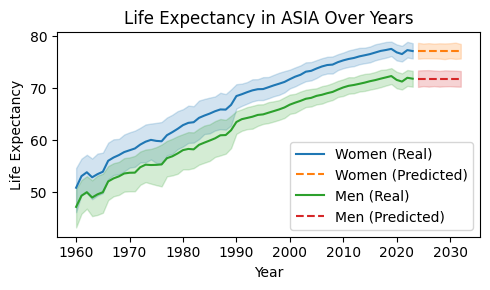

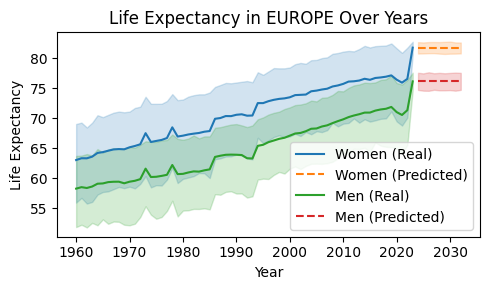

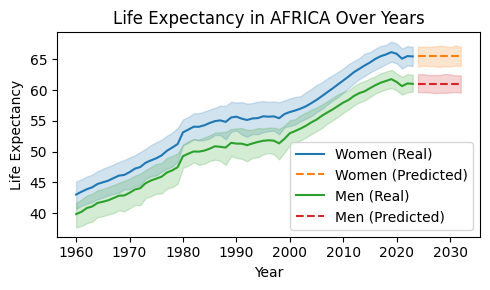

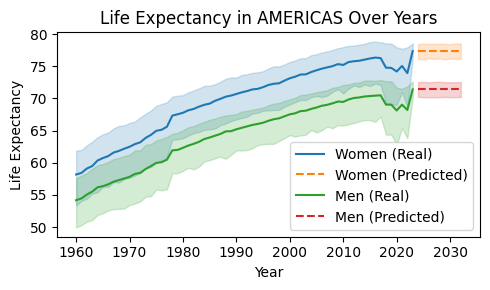

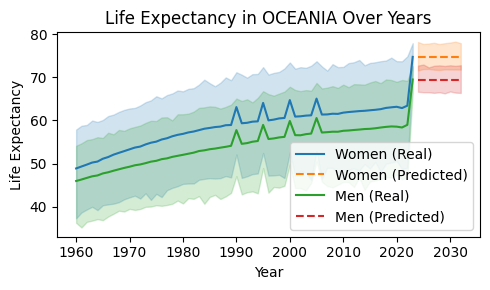

In [15]:
# 获取所有的区域
regions = data['region'].unique()

# 为每个 region 绘制折线图
for region in regions:
    plt.figure(figsize=(5, 3))
    region_data = data[data['region'] == region]
    
    # 为 Women 绘制折线
    sns.lineplot(data=region_data[region_data['year'] <= 2023],
                 x='year', y='life_expectancy_women',
                 label='Women (Real)', linestyle='-')
    sns.lineplot(data=region_data[region_data['year'] > 2023],
                 x='year', y='life_expectancy_women',
                 label='Women (Predicted)', linestyle='--')
    
    # 为 Men 绘制折线
    sns.lineplot(data=region_data[region_data['year'] <= 2023],
                 x='year', y='life_expectancy_men',
                 label='Men (Real)', linestyle='-')
    sns.lineplot(data=region_data[region_data['year'] > 2023],
                 x='year', y='life_expectancy_men',
                 label='Men (Predicted)', linestyle='--')
    
    plt.title(f'Life Expectancy in {region} Over Years')
    plt.xlabel('Year')
    plt.ylabel('Life Expectancy')
    plt.legend()
    plt.tight_layout()
    plt.show()